# Influence diagram

| | | |
|-|-|-|
|[ ![Creative Commons License](images/cc4.png)](http://creativecommons.org/licenses/by-nc/4.0/) |[ ![aGrUM](images/logoAgrum.png)](https://pyagrum.gitlab.io) |[ ![interactive online version](images/atbinder.svg)](https://mybinder.org/v2/gl/agrumery%2FaGrUM/forBinder?urlpath=%2Fdoc%2Ftree%2Fwrappers%2Fpyagrum%2Fdoc%2Fsphinx%2Fnotebooks%2F21-Models_InfluenceDiagram.ipynb)

In [1]:
import math

import pyagrum as gum
import pyagrum.lib.notebook as gnb

## Build a Influence Diagram

### fast build with string

In [2]:
gum.fastID("A->*B->$C<-D<-*E->*G->H->*I<-D")

(pyagrum.InfluenceDiagram@0x828431800) Influence Diagram{
  chance: 3,
  utility: 1,
  decision: 4,
  arcs: 8,
  domainSize: 128
}

### bgum format file

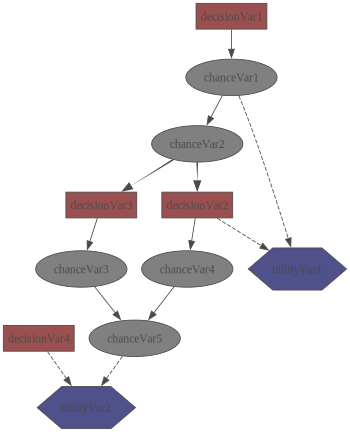

In [3]:
diag = gum.loadID("res/diag.bgum")
gnb.showInfluenceDiagram(diag)

In [4]:
diag

(pyagrum.InfluenceDiagram@0x828431e00) Influence Diagram{
  chance: 5,
  utility: 2,
  decision: 4,
  arcs: 12,
  domainSize: 512
}

### the hard way :-)

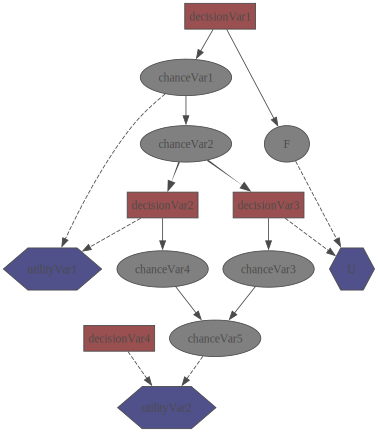

In [5]:
F = diag.addChanceNode(gum.LabelizedVariable("F", "F", 2))
diag.addArc(diag.idFromName("decisionVar1"), F)

U = diag.addUtilityNode(gum.LabelizedVariable("U", "U", 1))
diag.addArc(diag.idFromName("decisionVar3"), U)
diag.addArc(diag.idFromName("F"), U)
gnb.showInfluenceDiagram(diag)

In [6]:
diag.cpt(F)[{"decisionVar1": 0}] = [0.9, 0.1]
diag.cpt(F)[{"decisionVar1": 1}] = [0.3, 0.7]

diag.utility(U)[{"F": 0, "decisionVar3": 0}] = 2
diag.utility(U)[{"F": 0, "decisionVar3": 1}] = 4
diag.utility(U)[{"F": 1}] = [[0], [5]]

## Optimization in an influence diagram (actually LIMID)

In [7]:
oil = gum.loadID("res/OilWildcatter.bgum")
gnb.flow.row(oil, gnb.getInference(oil))

### Inference in the LIMID optimizing the decisions nodes

In [8]:
# a function to show results on decision nodes T and D
def show_decisions(ie):
  gnb.flow.row(
    ie.optimalDecision("Testing"),
    ie.optimalDecision("Drilling"),
    f"$${ie.MEU()['mean']:5.3f}\\ (stdev : {math.sqrt(ie.MEU()['variance']):5.3f})$$",
    captions=["Strategy for T", "Strategy for D", "MEU and its standard deviation"],
  )
  gnb.flow.row(
    ie.posterior("Testing"),
    ie.posteriorUtility("Testing"),
    ie.posterior("Drilling"),
    ie.posteriorUtility("Drilling"),
    captions=[
      "Final decision for Testing",
      "Final reward for Testing",
      "Final decision for Drilling",
      "Final reward for Drilling",
    ],
  )


ie = gum.ShaferShenoyLIMIDInference(oil)
ie.makeInference()
show_decisions(ie)

## Graphical inference with evidence and targets (developped nodes)

In [9]:
gnb.sideBySide(
  oil,
  gnb.getInference(oil, evs={"TestResult": "closed"}),
  gnb.getInference(oil, evs={"TestResult": "open"}),
  gnb.getInference(oil, evs={"TestResult": "diffuse"}),
  oil,
  gnb.getInference(oil, evs={"OilContents": "Dry"}),
  gnb.getInference(oil, evs={"OilContents": "Wet"}),
  gnb.getInference(oil, evs={"OilContents": "Soaking"}),
  ncols=4,
)

## Soft evidence on chance node

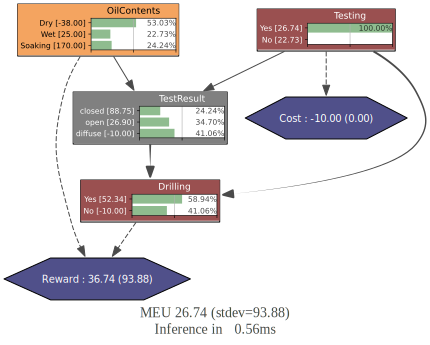

In [10]:
gnb.showInference(oil, evs={"OilContents": [0.7, 0.5, 0.8]})

## Forced decision

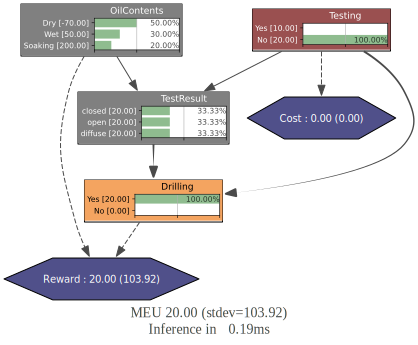

In [11]:
gnb.showInference(oil, evs={"Drilling": "Yes"})

## LIMID versus Influence Diagram

The default inference for influence diagram actually an inference for LIMIDs. In order to use it for classical (and solvable) influence diagram, do not forget to add the sequence of decision nodes using `addNoForgettingAssumption`.

In [12]:
infdiag = gum.fastID("Chance->*Decision1->Chance2->$Utility<-Chance3<-*Decision2<-Chance->Utility")
infdiag

(pyagrum.InfluenceDiagram@0x828432a00) Influence Diagram{
  chance: 3,
  utility: 1,
  decision: 2,
  arcs: 7,
  domainSize: 32
}

In [13]:
ie = gum.ShaferShenoyLIMIDInference(infdiag)
try:
  ie.makeInference()
except gum.GumException as e:
  print(e)

[pyAgrum] Fatal error: This LIMID/Influence Diagram is not solvable.


In [14]:
ie.addNoForgettingAssumption(["Decision1", "Decision2"])
gnb.sideBySide(ie.reducedLIMID(), ie.junctionTree(), gnb.getInference(infdiag, engine=ie))

"InfluenceDiagram <!-- Chance-Chance2-Decision1-Decision2 --> Chance-Chance2-Decision1-Decision2 (0):Chance,Chance2,Decision1,Decision2 <!-- Chance-Chance2-Decision1-Decision2+Chance-Chance2-Chance3-Decision2 --> Chance-Chance2-Decision1-Decision2+Chance-Chance2-Chance3-Decision2 Chance,Chance2,Decision2 <!-- Chance-Chance2-Decision1-Decision2--Chance-Chance2-Decision1-Decision2+Chance-Chance2-Chance3-Decision2 --> Chance-Chance2-Decision1-Decision2--Chance-Chance2-Decision1-Decision2+Chance-Chance2-Chance3-Decision2 <!-- Chance-Chance2-Chance3-Decision2 --> Chance-Chance2-Chance3-Decision2 (1):Chance,Chance2,Chance3,Decision2 <!-- Chance-Chance2-Decision1-Decision2+Chance-Chance2-Chance3-Decision2--Chance-Chance2-Chance3-Decision2 --> Chance-Chance2-Decision1-Decision2+Chance-Chance2-Chance3-Decision2--Chance-Chance2-Chance3-Decision2"


## Customizing visualization of the results

Using `pyagrum.config`, it is possible to adapt the graphical representations for Influence Diagram (see the notebook 99-Tools_configForPyAgrum.ipynb).

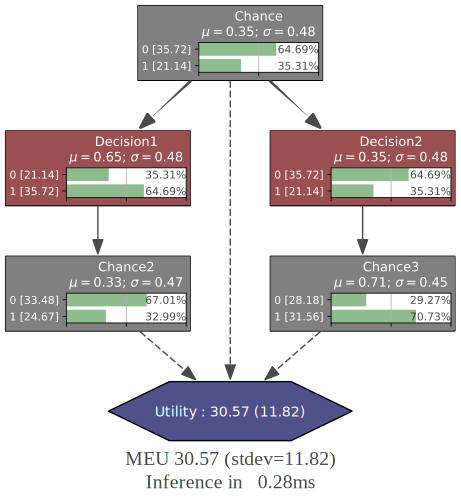

In [15]:
gum.config.reset()
gnb.showInference(infdiag, engine=ie, size="7!")

Many visual options can be changed when displaing an inference (especially for influence diagrams)


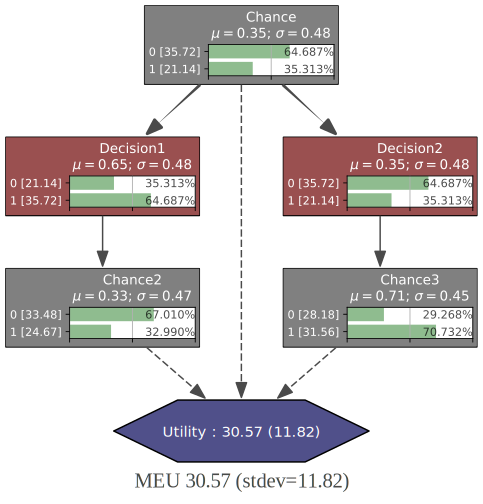

In [16]:
# do not show inference time
gum.config["notebook", "show_inference_time"] = False
# more digits for probabilities
gum.config["notebook", "histogram_horizontal_visible_digits"] = 3

gnb.showInference(infdiag, engine=ie, size="7!")

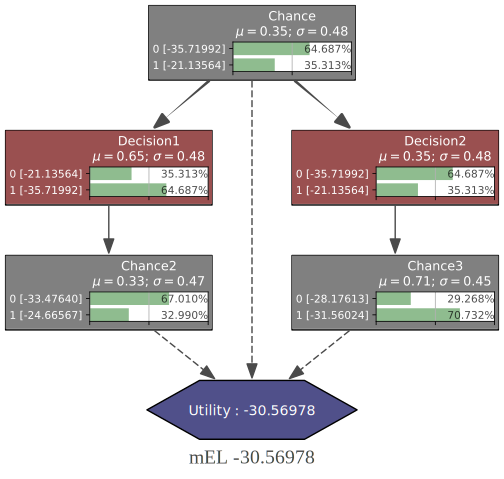

In [17]:
# specificic for influence diagram :
# more digits for utilities
gum.config["influenceDiagram", "utility_visible_digits"] = 5
# disabling stdev for utility and MEU
gum.config["influenceDiagram", "utility_show_stdev"] = False
# showing loss (=-utility) and mEL (minimum Expected Loss) instead of MEU
gum.config["influenceDiagram", "utility_show_loss"] = True

gnb.showInference(infdiag, engine=ie, size="7!")

In [18]:
# visual changes for influence diagram and inference
gum.config.reset()
gum.config.push()  # keep the current state
gum.config["notebook", "graph_rankdir"] = "LR"
gnb.sideBySide(infdiag, gnb.getInference(infdiag, engine=ie, targets=["Decision1", "Chance3"]))

In [19]:
# more visual changes for influence diagram and inference
gum.config.pop()  # back to the last state

# shape (https://graphviz.org/doc/info/shapes.html)
gum.config["influenceDiagram", "chance_shape"] = "cylinder"
gum.config["influenceDiagram", "utility_shape"] = "star"
gum.config["influenceDiagram", "decision_shape"] = "box3d"

# colors
gum.config["influenceDiagram", "default_chance_bgcolor"] = "green"
gum.config["influenceDiagram", "default_utility_bgcolor"] = "MediumVioletRed"
gum.config["influenceDiagram", "default_decision_bgcolor"] = "DarkSalmon"

gum.config["influenceDiagram", "utility_show_stdev"] = False

gnb.sideBySide(infdiag, gnb.getInference(infdiag, engine=ie, targets=["Decision1", "Chance3"]))